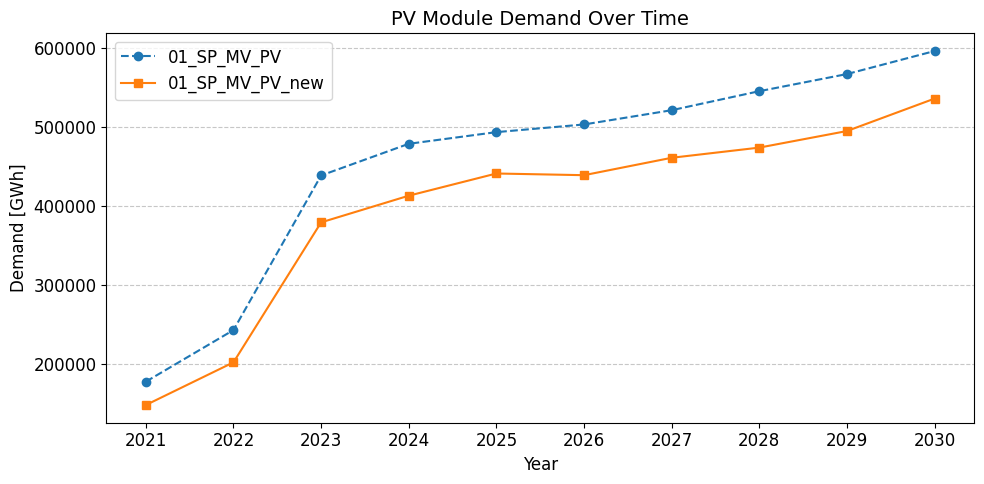

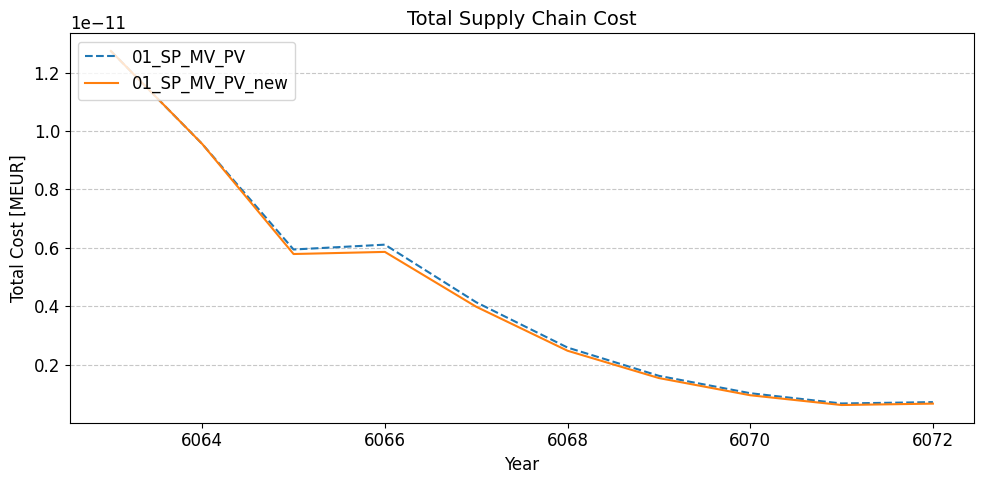

In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from zen_garden.postprocess.results import Results

# === Dataset Setup ===
dataset_name_1 = '01_SP_MV_PV'
dataset_name_2 = '01_SP_MV_PV_new'
r1 = Results(os.path.join("outputs", dataset_name_1))
r2 = Results(os.path.join("outputs", dataset_name_2))

# === Plot Save Settings ===
save_plots = True
save_path = Path(r"C:\Users\nicol\OneDrive\Desktop\Semester_project\Plots_and_Figures\SCM_plots\pv_comparison")
if save_plots:
    os.makedirs(save_path, exist_ok=True)

# === Plotting Styles ===
start_year = 2021
marker_styles = {dataset_name_1: 'o', dataset_name_2: 's'}
colors = {dataset_name_1: '#1f77b4', dataset_name_2: '#ff7f0e'}
linestyles = {dataset_name_1: '--', dataset_name_2: '-'}
line_widths = {dataset_name_1: 1.5, dataset_name_2: 1.5}


# === PV Demand Plot ===
def plot_pv_module_demand():
    try:
        df1 = r1.get_full_ts("demand").reset_index()
        df2 = r2.get_full_ts("demand").reset_index()

        df1 = df1[df1["carrier"] == "pv_module"]
        df2 = df2[df2["carrier"] == "pv_module"]

        time_cols = [col for col in df1.columns if isinstance(col, (int, float))]

        total1 = df1[time_cols].sum()
        total2 = df2[time_cols].sum()

        plt.figure(figsize=(10, 5))
        plt.plot(
            time_cols, total1,
            label=dataset_name_1,
            color=colors[dataset_name_1],
            linestyle=linestyles[dataset_name_1],
            marker=marker_styles[dataset_name_1],
            linewidth=line_widths[dataset_name_1]
        )
        plt.plot(
            time_cols, total2,
            label=dataset_name_2,
            color=colors[dataset_name_2],
            linestyle=linestyles[dataset_name_2],
            marker=marker_styles[dataset_name_2],
            linewidth=line_widths[dataset_name_2]
        )

        plt.title("PV Module Demand Over Time", fontsize=14)
        plt.xlabel("Year")
        plt.ylabel("Demand [GWh]")
        plt.grid(axis='y', linestyle="--", alpha=0.7)
        plt.legend(loc='upper left')
        plt.tight_layout()

        xtick_labels = [str(start_year + i) for i in range(len(time_cols))]
        plt.xticks(ticks=time_cols, labels=xtick_labels)

        if save_plots:
            plt.savefig(save_path / "pv_module_demand.pdf", format='pdf', bbox_inches='tight')

        plt.show()

    except Exception as e:
        print(f"⚠️ Error plotting PV demand: {e}")


# === Total Cost Plot ===
def plot_cost_total(cost1, cost2, ylabel="Total Cost [MEUR]", title="Total Supply Chain Cost", file_prefix="cost_total"):
    # Convert year to actual year
    cost1["year"] = cost1["year"] + 2021
    cost2["year"] = cost2["year"] + 2021

    # Convert to MEUR (assuming value is in EUR)
    cost1["value"] = cost1["value"] / 1e6
    cost2["value"] = cost2["value"] / 1e6

    plt.figure(figsize=(10, 5))
    plt.plot(cost1["year"], cost1["value"], label='01_SP_MV_PV', linestyle='--', color='tab:blue')
    plt.plot(cost2["year"], cost2["value"], label='01_SP_MV_PV_new', linestyle='-', color='tab:orange')

    plt.title(title, fontsize=14)
    plt.xlabel("Year")
    plt.ylabel(ylabel)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(loc='upper left')
    plt.tight_layout()

    if save_plots:
        filename = f"{file_prefix}.pdf"
        plt.savefig(save_path / filename, format='pdf', bbox_inches='tight')

    plt.show()

# === Run Plots ===
plot_pv_module_demand()
plot_cost_total(cost1, cost2)
